# 01 — PatchCamelyon dataset exploration

Inspect shapes, class balance, and sample patches.

**Prerequisite:** activate the `pathsight` pyenv environment (pinned via `.python-version`) and ensure the model package and notebook dependencies are installed:
```bash
pyenv activate pathsight   # or: pyenv shell pathsight
cd model && pip install -r requirements.txt && pip install -e . && cd ..
pip install -r notebooks/requirements.txt
```
Select the **pathsight** kernel in Jupyter before running cells.

In [1]:
import model_service
print(model_service.__file__)

/Users/shayan/code/sandinosaso/pathsight/model/src/model_service/__init__.py


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from model_service.config import ModelServiceConfig
from model_service.constants import LABEL_NAMES
from model_service.preprocess.dataset_builder import build_pcam_datasets
from model_service.preprocess.tfds_pcam_loader import load_pcam_splits

print("TensorFlow:", tf.__version__)
print("Label names:", LABEL_NAMES)

TensorFlow: 2.16.2
Label names: ('non_metastatic', 'metastatic')


In [3]:
# Downloads PCam via TFDS on first run (~7 GB); uses cached data on subsequent runs.
train_raw, val_raw, test_raw, info = load_pcam_splits(download=True)
print(info)
print("\nSplits:", info.splits)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/shayan/tensorflow_datasets/patch_camelyon/incomplete.469536_2.0.0/patch_camelyon-train.tfreco…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/shayan/tensorflow_datasets/patch_camelyon/incomplete.469536_2.0.0/patch_camelyon-validation.t…

Dataset patch_camelyon downloaded and prepared to /Users/shayan/tensorflow_datasets/patch_camelyon/2.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='patch_camelyon',
    full_name='patch_camelyon/2.0.0',
    description="""
    The PatchCamelyon benchmark is a new and challenging image classification
    dataset. It consists of 327.680 color images (96 x 96px) extracted from
    histopathologic scans of lymph node sections. Each image is annoted with a
    binary label indicating presence of metastatic tissue. PCam provides a new
    benchmark for machine learning models: bigger than CIFAR10, smaller than
    Imagenet, trainable on a single GPU.
    """,
    homepage='https://patchcamelyon.grand-challenge.org/',
    data_dir='/Users/shayan/tensorflow_datasets/patch_camelyon/2.0.0',
    file_format=tfrecord,
    download_size=7.48 GiB,
    dataset_size=7.06 GiB,
    features=FeaturesDict({
        'id': Text(shape=(), dtype=string),
        'image': Image(sh

In [4]:
def count_labels(ds, steps: int = 2000):
    neg = pos = 0
    for _, y in ds.take(steps):
        if int(y.numpy()) == 1:
            pos += 1
        else:
            neg += 1
    return neg, pos

n0, n1 = count_labels(train_raw, steps=2000)
total = n0 + n1
print(f"Sample of first 2000 train examples:")
print(f"  {LABEL_NAMES[0]}: {n0} ({n0/total:.1%})")
print(f"  {LABEL_NAMES[1]}: {n1} ({n1/total:.1%})")

2026-04-20 20:09:55.603460: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:376] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Sample of first 2000 train examples:
  non_metastatic: 992 (49.6%)
  metastatic: 1008 (50.4%)


2026-04-20 20:09:55.865149: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Saved to /Users/shayan/code/sandinosaso/pathsight/artifacts/figures/01_sample_patches.png


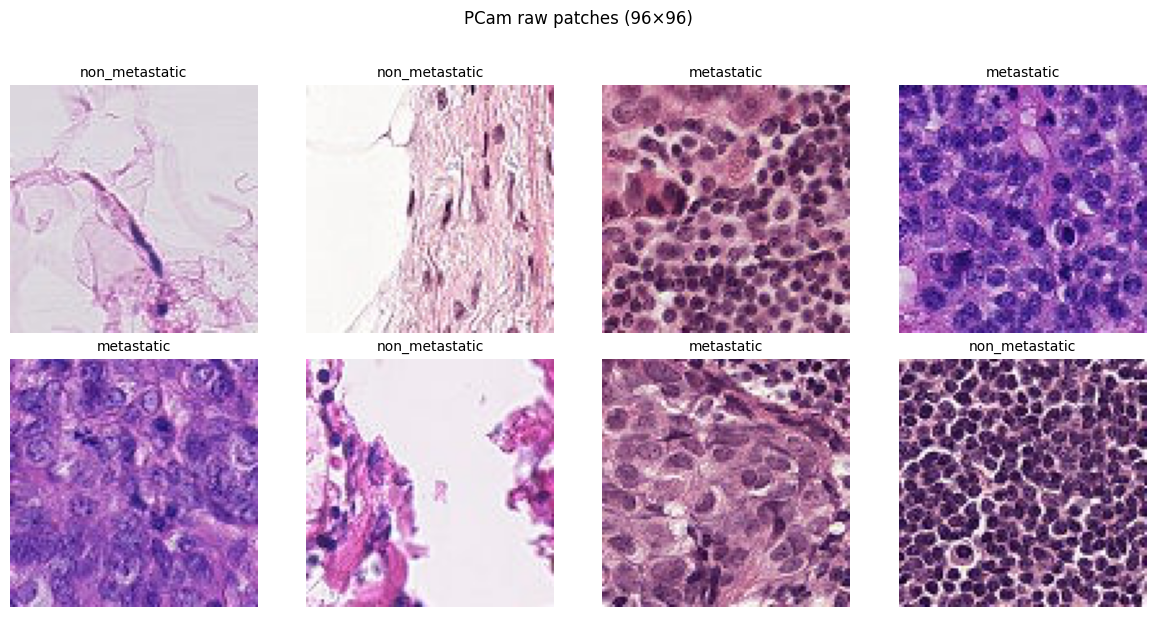

In [11]:
# Visualise 8 sample patches (raw 96×96 images)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
for ax, (img, lab) in zip(axes, train_raw.take(8)):
    ax.imshow(img.numpy())
    ax.set_title(LABEL_NAMES[int(lab.numpy())], fontsize=10)
    ax.axis("off")
plt.suptitle("PCam raw patches (96×96)", y=1.02)
plt.tight_layout()

out = REPO_ROOT / "artifacts" / "figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "01_sample_patches.png", dpi=150, bbox_inches="tight")
print("Saved to", out / "01_sample_patches.png")

In [17]:
# Verify the full data pipeline: shapes must be (32, 224, 224, 3) and (32,)
cfg = ModelServiceConfig()
cfg.data.batch_size = 8  # small for notebook speed
train_ds, val_ds, test_ds, _ = build_pcam_datasets(cfg, download=False)
xb, yb = next(iter(train_ds))
print("Batch images :", xb.shape, "dtype", xb.dtype)
print("Batch labels :", yb.shape, "dtype", yb.dtype)
print("Pixel range  : [{:.4f}, {:.4f}]".format(float(xb.numpy().min()), float(xb.numpy().max())))
assert list(xb.shape[1:]) == [224, 224, 3], "Expected (B,224,224,3)"
assert xb.numpy().min() >= 0.0 and xb.numpy().max() <= 1.0, "Pixels not in [0,1]"
assert set(yb.numpy().astype(int).tolist()).issubset({0, 1}), "Labels not binary"
print("All assertions passed ✓")

Batch images : (8, 96, 96, 3) dtype <dtype: 'uint8'>
Batch labels : (8,) dtype <dtype: 'int64'>
Pixel range  : [0.0000, 255.0000]


AssertionError: Expected (B,224,224,3)

In [16]:
xb.shape

TensorShape([10, 96, 96, 3])